In [ ]:
import os
import cv2
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imtkaggleteam/kidney-stone-classification-and-object-detection")

print("Path to dataset files:", path)

100%|██████████| 215M/215M [00:13<00:00, 16.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/imtkaggleteam/kidney-stone-classification-and-object-detection/versions/1


Task 1: Image Classification¶
This task focuses on preparing and visualizing the dataset for a binary image classification problem involving two categories: Normal and Stone.


In [ ]:
# -------------------- Load Image Paths --------------------
# Collect paths for images under 'Normal' and 'Stone' categories
image_list_stone = []
image_list_normal = []

for normal in os.listdir(path + "/Normal"):
    if normal.endswith(".JPG"):
        image_list_normal.append(os.path.join(path + "/Normal", normal))

for stone in os.listdir(path + "/stone"):
    if stone.endswith(".JPG"):
        image_list_stone.append(os.path.join(path + "/stone", stone))

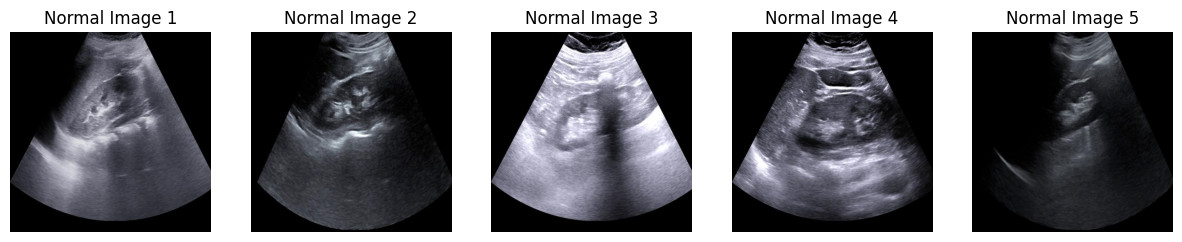

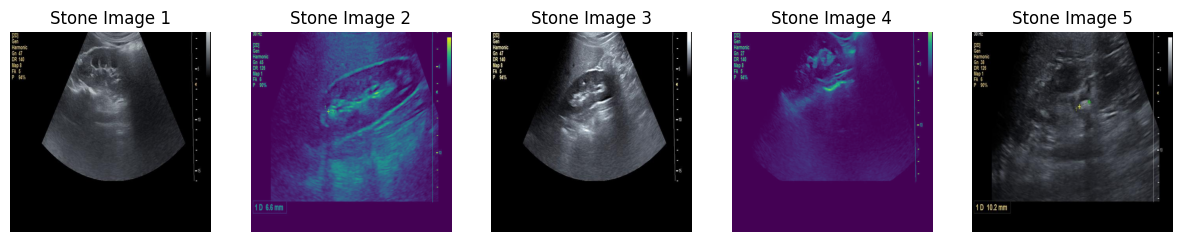

In [ ]:
# -------------------- Display 5 Random Images from Each Class --------------------
random_images_normal = random.sample(image_list_normal, 5)
random_images_stone = random.sample(image_list_stone, 5)

plt.figure(figsize=(15, 10))
for i, img_path in enumerate(random_images_normal):
    plt.subplot(1, 5, i + 1)
    plt.title("Normal Image " + str(i + 1))
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
plt.show()

plt.figure(figsize=(15, 10))
for i, img_path in enumerate(random_images_stone):
    plt.subplot(1, 5, i + 1)
    plt.title("Stone Image " + str(i + 1))
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [ ]:
# -------------------- Split Data into Training, Validation, and Test Sets --------------------
train_size = 0.7
val_size = 0.2
test_size = 0.1

# Split for normal class
train_normal, test_normal = train_test_split(image_list_normal, test_size=test_size, random_state=42)
train_normal, val_normal = train_test_split(train_normal, test_size=val_size, random_state=42)

# Split for stone class
train_stone, test_stone = train_test_split(image_list_stone, test_size=test_size, random_state=42)
train_stone, val_stone = train_test_split(train_stone, test_size=val_size, random_state=42)

print(f"Number of training images (Normal): {len(train_normal)}")
print(f"Number of validation images (Normal): {len(val_normal)}")
print(f"Number of testing images (Normal): {len(test_normal)}")
print(f"Number of training images (Stone): {len(train_stone)}")
print(f"Number of validation images (Stone): {len(val_stone)}")
print(f"Number of testing images (Stone): {len(test_stone)}")

Number of training images (Normal): 3177
Number of validation images (Normal): 795
Number of testing images (Normal): 442
Number of training images (Stone): 3600
Number of validation images (Stone): 901
Number of testing images (Stone): 501


In [ ]:
# -------------------- Create DataFrames --------------------
# Each dataframe contains image paths and labels
df_train_normal = pd.DataFrame({'image_path': train_normal, 'label': 'Normal'})
df_val_normal = pd.DataFrame({'image_path': val_normal, 'label': 'Normal'})
df_test_normal = pd.DataFrame({'image_path': test_normal, 'label': 'Normal'})

df_train_stone = pd.DataFrame({'image_path': train_stone, 'label': 'Stone'})
df_val_stone = pd.DataFrame({'image_path': val_stone, 'label': 'Stone'})
df_test_stone = pd.DataFrame({'image_path': test_stone, 'label': 'Stone'})

# Combine and shuffle data
df_train = pd.concat([df_train_normal, df_train_stone]).sample(frac=1, random_state=42).reset_index(drop=True)
df_val = pd.concat([df_val_normal, df_val_stone]).sample(frac=1, random_state=42).reset_index(drop=True)
df_test = pd.concat([df_test_normal, df_test_stone]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nTraining DataFrame:")
print(df_train.head())
print("\nValidation DataFrame:")
print(df_val.head())
print("\nTesting DataFrame:")
print(df_test.head())

print(f"\nTotal training samples: {len(df_train)}")
print(f"Total validation samples: {len(df_val)}")
print(f"Total testing samples: {len(df_test)}")


Training DataFrame:
                                          image_path   label
0  /root/.cache/kagglehub/datasets/imtkaggleteam/...   Stone
1  /root/.cache/kagglehub/datasets/imtkaggleteam/...   Stone
2  /root/.cache/kagglehub/datasets/imtkaggleteam/...  Normal
3  /root/.cache/kagglehub/datasets/imtkaggleteam/...  Normal
4  /root/.cache/kagglehub/datasets/imtkaggleteam/...  Normal

Validation DataFrame:
                                          image_path   label
0  /root/.cache/kagglehub/datasets/imtkaggleteam/...  Normal
1  /root/.cache/kagglehub/datasets/imtkaggleteam/...  Normal
2  /root/.cache/kagglehub/datasets/imtkaggleteam/...  Normal
3  /root/.cache/kagglehub/datasets/imtkaggleteam/...  Normal
4  /root/.cache/kagglehub/datasets/imtkaggleteam/...   Stone

Testing DataFrame:
                                          image_path   label
0  /root/.cache/kagglehub/datasets/imtkaggleteam/...  Normal
1  /root/.cache/kagglehub/datasets/imtkaggleteam/...  Normal
2  /root/.cache/kaggl

In [ ]:
# -------------------- Set Model Parameters --------------------
Batch_size = 64
Img_height = 512
Img_width = 512

In [ ]:
# -------------------- Create Image Data Generators --------------------
# Rescale pixel values to range [0, 1]
trainGenerator = ImageDataGenerator(rescale=1. / 255.)
valGenerator = ImageDataGenerator(rescale=1. / 255.)
testGenerator = ImageDataGenerator(rescale=1. / 255.)

In [ ]:
# -------------------- Load Data Using flow_from_dataframe --------------------
trainDataset = trainGenerator.flow_from_dataframe(
    dataframe=df_train,
    class_mode="categorical",
    x_col="image_path",
    y_col="label",
    batch_size=Batch_size,
    seed=42,
    shuffle=True,
    target_size=(Img_height, Img_width)
)

testDataset = testGenerator.flow_from_dataframe(
    dataframe=df_test,
    class_mode='categorical',
    x_col="image_path",
    y_col="label",
    batch_size=Batch_size,
    seed=42,
    shuffle=False,
    target_size=(Img_height, Img_width)
)

valDataset = valGenerator.flow_from_dataframe(
    dataframe=df_val,
    class_mode='categorical',
    x_col="image_path",
    y_col="label",
    batch_size=Batch_size,
    seed=42,
    shuffle=True,
    target_size=(Img_height, Img_width)
)

Found 6777 validated image filenames belonging to 2 classes.
Found 943 validated image filenames belonging to 2 classes.
Found 1696 validated image filenames belonging to 2 classes.


In [ ]:
# -------------------- Define the CNN Model (Inspired by AlexNet) --------------------
model = Sequential([
    Conv2D(96, (11, 11), activation='relu', strides=(4, 4), input_shape=(Img_height, Img_width, 3)),
    MaxPooling2D((3, 3), strides=(2, 2)),
    Conv2D(256, (5, 5), activation='relu', padding='same'),
    MaxPooling2D((3, 3), strides=(2, 2)),
    Conv2D(384, (3, 3), activation='relu', padding='same'),
    Conv2D(384, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((3, 3), strides=(2, 2)),
    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # Output layer for 2 classes
])

# -------------------- Compile the Model --------------------
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 96)   │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   205,524,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,061,698 (862.36 MB)

 Trainable params: 226,061,698 (862.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# -------------------- Train the Model --------------------
Alex_model = model.fit(trainDataset, epochs=7, validation_data=valDataset)

Epoch 1/7
106/106 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9720 - loss: 0.0624 - val_accuracy: 1.0000 - val_loss: 9.6127e-04
Epoch 2/7
106/106 ━━━━━━━━━━━━━━━━━━━━ 65s 613ms/step - accuracy: 1.0000 - loss: 4.1303e-04 - val_accuracy: 0.9994 - val_loss: 0.0011
Epoch 3/7
106/106 ━━━━━━━━━━━━━━━━━━━━ 65s 613ms/step - accuracy: 1.0000 - loss: 2.1885e-05 - val_accuracy: 1.0000 - val_loss: 3.1769e-06
Epoch 4/7
106/106 ━━━━━━━━━━━━━━━━━━━━ 65s 607ms/step - accuracy: 0.9975 - loss: 0.0304 - val_accuracy: 0.9923 - val_loss: 0.0180
Epoch 5/7
106/106 ━━━━━━━━━━━━━━━━━━━━ 65s 611ms/step - accuracy: 0.9979 - loss: 0.0073 - val_accuracy: 0.9982 - val_loss: 0.0074
Epoch 6/7
106/106 ━━━━━━━━━━━━━━━━━━━━ 66s 616ms/step - accuracy: 1.0000 - loss: 1.8054e-04 - val_accuracy: 0.9988 - val_loss: 0.0078
Epoch 7/7
106/106 ━━━━━━━━━━━━━━━━━━━━ 69s 651ms/step - accuracy: 1.0000 - loss: 6.8846e-06 - val_accuracy: 0.9988 - val_loss: 0.0048


15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step

Confusion Matrix:
[[442   0]
 [  0 501]]


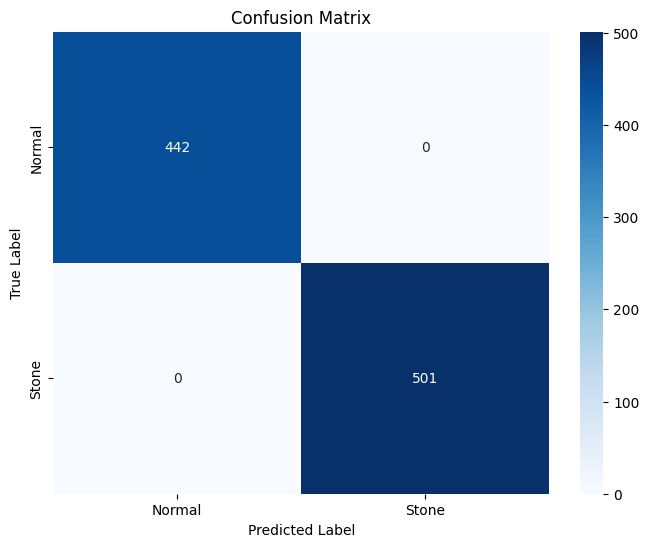

In [ ]:
# -------------------- Confusion Matrix Visualization --------------------
# Get predictions from the model on the test dataset
predictions = model.predict(testDataset)

# Get predicted classes (index of the highest probability)
predicted_classes_single = np.argmax(predictions, axis=1)

# Get true labels from the test dataset
true_labels = testDataset.classes

cm = confusion_matrix(true_labels, predicted_classes_single)
class_labels = list(testDataset.class_indices.keys())

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Task 2
Object Detection of Kidney Stones¶
This task builds upon the initial classification problem by performing object detection to not only identify but also precisely locate kidney stones within images.

In [ ]:
# Install the 'ultralytics' package, which provides access to YOLOv5, YOLOv8, and other state-of-the-art object detection models
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.3 MB/s eta 0:00:00


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("safurahajiheidari/kidney-stone-images")

print("Path to dataset files:", path)

100%|██████████| 21.1M/21.1M [00:02<00:00, 9.59MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/safurahajiheidari/kidney-stone-images/versions/1


In [ ]:
import ultralytics
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os

# Define the path to the dataset configuration YAML file
yaml_path = os.path.join(path, 'data.yaml')

# Set the directory path containing training images
train_path = os.path.join(path, 'train', 'images')

# Set the directory path containing validation images
valid_path = os.path.join(path, 'valid', 'images')

In [ ]:
# Load a pre-trained YOLO model (YOLOv11 Nano version) from the specified weights file
model = YOLO('yolo11n.pt')

In [ ]:
# -------------------- Train the Model --------------------
# Train the YOLO model using the dataset specified in the YAML configuration
# - 'data': path to the dataset config file defining train/val splits and class names
# - 'epochs': number of training iterations over the entire dataset
# - 'batch': batch size for training
# - 'plots': enables live plotting of training metrics such as loss and accuracy
results = model.train(
    data=yaml_path,
    epochs=15,
    batch=8,  # Further reduced batch size to mitigate OutOfMemoryError
    plots=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/safurahajiheidari/kidney-stone-images/versions/1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False,

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 1.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 971.51 MiB is allocated by PyTorch, and 20.49 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:

import glob
import cv2
import matplotlib.pyplot as plt

# Directory where training detection results are saved (e.g., output images)
data_dir = "runs/detect/train"

# Pattern to match all image files (e.g., jpg, png) in the results directory
img_dir = os.path.join(data_dir, '*g')

# Retrieve list of image file paths matching the pattern
files = glob.glob(img_dir)

imgs = []
for image in files:
    # Read each image using OpenCV
    img = cv2.imread(image)
    imgs.append(img)

    # Display the image with high resolution and large figure size
    plt.figure(figsize=(10, 10), dpi=200)
    plt.imshow(img)
    plt.axis('off')  # Hide axis for cleaner visualization
    plt.show()

In [ ]:
# Define the path to the directory containing test images
test_path = os.path.join(path, 'test', 'images')

# Use the trained YOLO model to perform inference on images in the test directory
# - 'source': directory or file to run prediction on
# - 'save': save annotated prediction images to disk
# - 'save_txt': save prediction results as text files (bounding box coordinates, class, confidence)
results = model.predict(
    source=test_path,
    save=True,
    save_txt=True
)

In [ ]:
import random
# Get the total number of prediction results
total_results = len(results)

# Randomly select 10 unique indices from the prediction results
random_indices = random.sample(range(total_results), 10)

for i in random_indices:
    # Generate an image with predicted bounding boxes and labels overlaid
    img = results[i].plot()

    # Set figure size for better visualization
    plt.figure(figsize=(10, 6))

    # Display the annotated image
    plt.imshow(img)

    # Hide axis ticks and labels for a cleaner look
    plt.axis('off')

    # Add a title indicating the prediction index
    plt.title(f'Random Prediction {i+1}')

    # Show the plot
    plt.show()